## Arbol de decision

Carpeta actual: d:\HELEN\PERSONAL\FORMACIÓN\IA - FORMACION\F5 - INTRODUCCIÓN IA\TRABAJO - Evaluador de Sesgo y Fuga de Talento STEM\Evaluador-de-Sesgo-y-Fuga-de-Talento-STEM\notebooks

Shape del dataset: (100, 11)


,id,edad,anios_experiencia,salario_anual,tamano_empresa,teletrabajo,politicas_conciliacion,satisfaccion_laboral,brecha_salarial_percibida,anios_en_puesto,abandona
0,1,24,1,28000,pequena,si,no,baja,si,1,si
1,2,25,2,30000,pequena,si,no,media,si,1,si
2,3,26,3,32000,mediana,si,si,alta,no,2,no
3,4,27,4,34000,mediana,no,no,baja,si,2,si
4,5,28,5,36000,grande,si,si,alta,no,3,no



Columnas:
['id', 'edad', 'anios_experiencia', 'salario_anual', 'tamano_empresa', 'teletrabajo', 'politicas_conciliacion', 'satisfaccion_laboral', 'brecha_salarial_percibida', 'anios_en_puesto', 'abandona']

Tipos de datos:
id                           int64
edad                         int64
anios_experiencia            int64
salario_anual                int64
tamano_empresa                 str
teletrabajo                    str
politicas_conciliacion         str
satisfaccion_laboral           str
brecha_salarial_percibida      str
anios_en_puesto              int64
abandona                       str
dtype: object

Valores nulos:
id                           0
edad                         0
anios_experiencia            0
salario_anual                0
tamano_empresa               0
teletrabajo                  0
politicas_conciliacion       0
satisfaccion_laboral         0
brecha_salarial_percibida    0
anios_en_puesto              0
abandona                     0
dtype: int64

Distri

C:\Users\elena\AppData\Local\Temp\ipykernel_52824\758357915.py:64: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns.tolist()


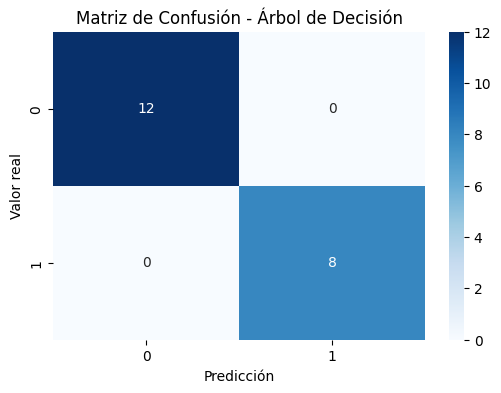


Importancia de variables:


,variable,importancia
6,politicas_conciliacion_si,1.0
0,tamano_empresa_grande,0.0
2,tamano_empresa_pequena,0.0
1,tamano_empresa_mediana,0.0
3,teletrabajo_no,0.0
4,teletrabajo_si,0.0
5,politicas_conciliacion_no,0.0
7,satisfaccion_laboral_alta,0.0
8,satisfaccion_laboral_baja,0.0
9,satisfaccion_laboral_media,0.0


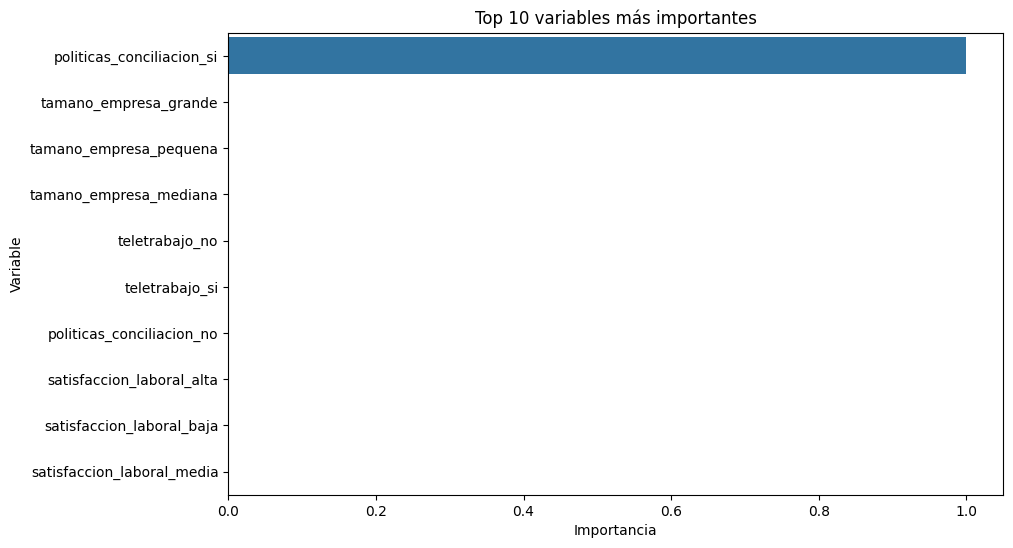

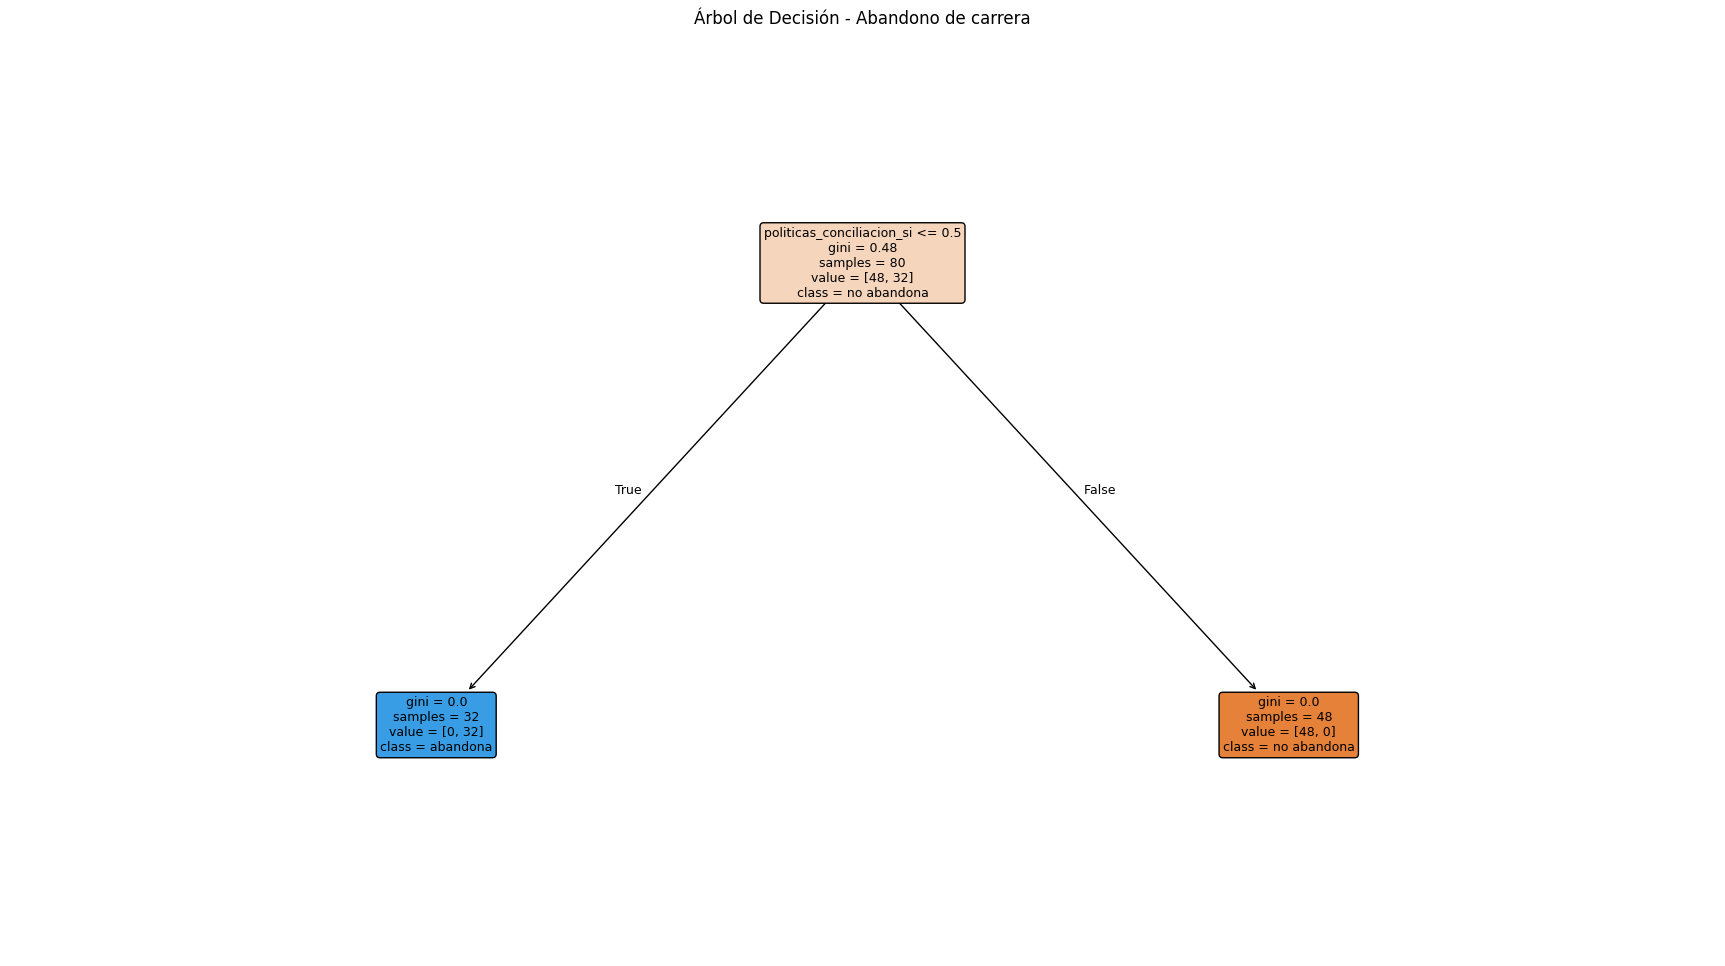


Ejemplo de predicción:


,edad,anios_experiencia,salario_anual,tamano_empresa,teletrabajo,politicas_conciliacion,satisfaccion_laboral,brecha_salarial_percibida,anios_en_puesto
0,30,7,41000,pequena,no,no,baja,si,4


Predicción: abandona
Probabilidades [no abandona, abandona]: [0. 1.]


In [12]:
# ==========================================
# NOTEBOOK: 01_arbol_decision.ipynb
# OBJETIVO:
# Predecir si una mujer abandona o no su carrera tech
# usando un Árbol de Decisión
# ==========================================

# ==========
# 1. LIBRERÍAS
# ==========
import os
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========
# 2. DETECTAR RUTA BASE
# ==========
print("Carpeta actual:", os.getcwd())

if Path("data/processed").exists():
    BASE_PATH = Path(".")
elif Path("../data/processed").exists():
    BASE_PATH = Path("..")
else:
    raise FileNotFoundError("No se encontró la carpeta data/processed")

PROCESSED_PATH = BASE_PATH / "data" / "processed"

# ==========
# 3. CARGAR DATASET LIMPIO
# ==========
file_path = PROCESSED_PATH / "women_tech_attrition_clean.csv"
df = pd.read_csv(file_path)

print("\nShape del dataset:", df.shape)
display(df.head())

# ==========
# 4. REVISIÓN BÁSICA
# ==========
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

# ==========
# 5. NORMALIZAR TEXTO POR SI HAY MAYÚSCULAS O ESPACIOS
# ==========
text_cols = df.select_dtypes(include="object").columns.tolist()

for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

# ==========
# 6. PREPARAR VARIABLE OBJETIVO
# Convertimos abandona: si/no -> 1/0
# ==========
df["abandona"] = df["abandona"].map({"si": 1, "no": 0})

# Eliminar filas con target nulo por si hubiera algún valor raro
df = df.dropna(subset=["abandona"]).reset_index(drop=True)

# Asegurar que abandona sea entero
df["abandona"] = df["abandona"].astype(int)

print("\nDistribución de la variable objetivo:")
print(df["abandona"].value_counts())

# ==========
# 7. SELECCIONAR VARIABLES
# ==========
features = [
    "edad",
    "anios_experiencia",
    "salario_anual",
    "tamano_empresa",
    "teletrabajo",
    "politicas_conciliacion",
    "satisfaccion_laboral",
    "brecha_salarial_percibida",
    "anios_en_puesto"
]

target = "abandona"

X = df[features].copy()
y = df[target].copy()

# ==========
# 8. DEFINIR VARIABLES NUMÉRICAS Y CATEGÓRICAS
# ==========
categorical_features = [
    "tamano_empresa",
    "teletrabajo",
    "politicas_conciliacion",
    "satisfaccion_laboral",
    "brecha_salarial_percibida"
]

numeric_features = [
    "edad",
    "anios_experiencia",
    "salario_anual",
    "anios_en_puesto"
]

# ==========
# 9. PREPROCESADO
# OneHotEncoder transforma texto a columnas numéricas binarias
# ==========
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# ==========
# 10. CREAR PIPELINE COMPLETO
# ==========
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

# ==========
# 11. DIVIDIR TRAIN / TEST
# ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

# ==========
# 12. ENTRENAR EL MODELO
# ==========
model.fit(X_train, y_train)

# ==========
# 13. HACER PREDICCIONES
# ==========
y_pred = model.predict(X_test)

# ==========
# 14. EVALUAR EL MODELO
# ==========
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy del modelo:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========
# 15. MATRIZ DE CONFUSIÓN
# ==========
cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusión:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# ==========
# 16. IMPORTANCIA DE VARIABLES
# ==========
# Recuperar nombres de columnas después del OneHotEncoder
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_names) + numeric_features

tree_model = model.named_steps["classifier"]

importance_df = pd.DataFrame({
    "variable": all_feature_names,
    "importancia": tree_model.feature_importances_
}).sort_values(by="importancia", ascending=False)

print("\nImportancia de variables:")
display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x="importancia",
    y="variable",
    hue="variable",
    dodge=False,
    legend=False
)
plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

# ==========
# 17. VISUALIZAR EL ÁRBOL
# ==========
plt.figure(figsize=(22, 12))
plot_tree(
    tree_model,
    feature_names=all_feature_names,
    class_names=["no abandona", "abandona"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de Decisión - Abandono de carrera")
plt.show()

# ==========
# 18. EJEMPLO DE PREDICCIÓN
# ==========
sample = pd.DataFrame([{
    "edad": 30,
    "anios_experiencia": 7,
    "salario_anual": 41000,
    "tamano_empresa": "pequena",
    "teletrabajo": "no",
    "politicas_conciliacion": "no",
    "satisfaccion_laboral": "baja",
    "brecha_salarial_percibida": "si",
    "anios_en_puesto": 4
}])

pred = model.predict(sample)[0]
proba = model.predict_proba(sample)[0]

print("\nEjemplo de predicción:")
display(sample)

if pred == 1:
    print("Predicción: abandona")
else:
    print("Predicción: no abandona")

print("Probabilidades [no abandona, abandona]:", proba)